In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/DataCoSupplyChainDataset.csv", encoding="latin1")

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [2]:
df.shape


(180519, 53)

In [3]:
df.columns.tolist()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Image',
 'Product Name',
 'Product P

In [4]:
df.isnull().sum().sort_values(ascending=False).head(30)

Product Description              180519
Order Zipcode                    155679
Customer Lname                        8
Customer Zipcode                      3
Days for shipment (scheduled)         0
Sales per customer                    0
Benefit per order                     0
Delivery Status                       0
Late_delivery_risk                    0
Customer City                         0
Customer Country                      0
Category Id                           0
Category Name                         0
Customer Fname                        0
Customer Email                        0
Customer Password                     0
Customer Id                           0
Customer Segment                      0
Customer State                        0
Days for shipping (real)              0
Type                                  0
Department Id                         0
Customer Street                       0
Department Name                       0
Latitude                              0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["Late_delivery_risk"].value_counts()

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

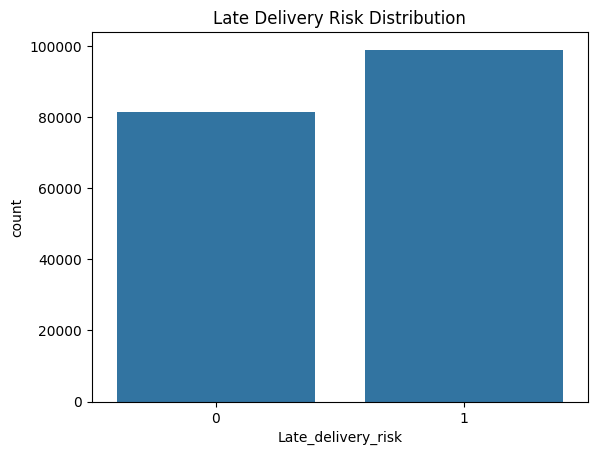

In [7]:
sns.countplot(data=df, x="Late_delivery_risk")
plt.title("Late Delivery Risk Distribution")
plt.show()

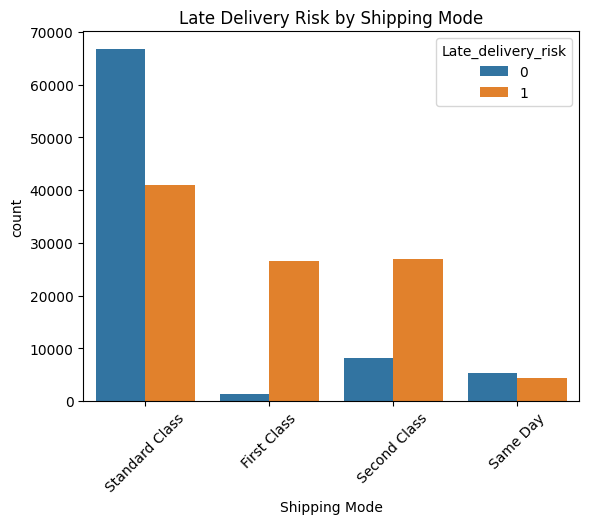

In [8]:
sns.countplot(data=df, x="Shipping Mode", hue="Late_delivery_risk")
plt.title("Late Delivery Risk by Shipping Mode")
plt.xticks(rotation=45)
plt.show()

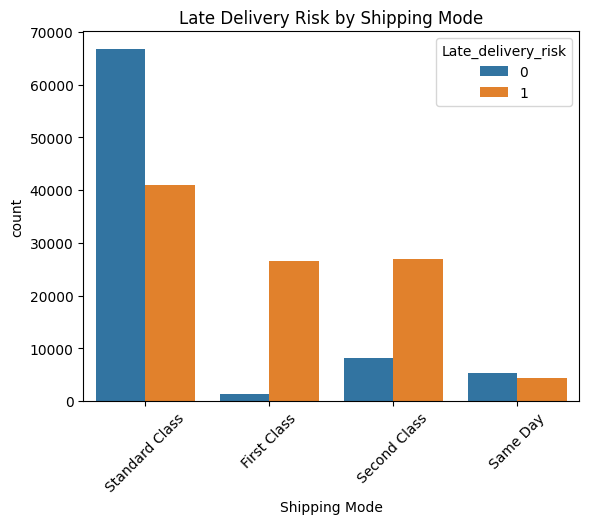

In [9]:
sns.countplot(data=df, x="Shipping Mode", hue="Late_delivery_risk")
plt.title("Late Delivery Risk by Shipping Mode")
plt.xticks(rotation=45)
plt.show()

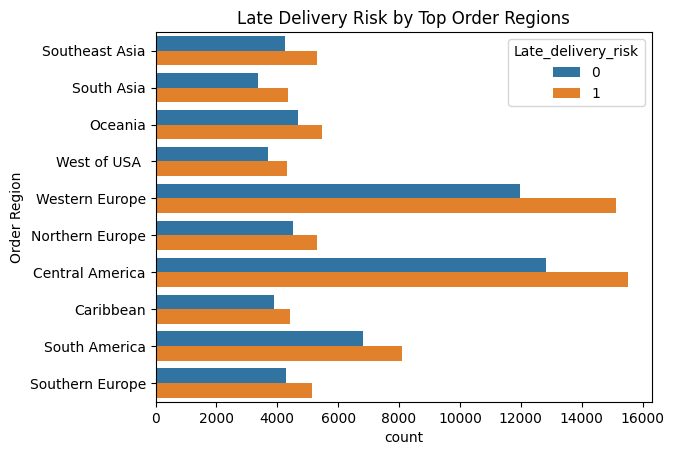

In [10]:
top_regions = df["Order Region"].value_counts().head(10).index
sns.countplot(data=df[df["Order Region"].isin(top_regions)], y="Order Region", hue="Late_delivery_risk")
plt.title("Late Delivery Risk by Top Order Regions")
plt.show()

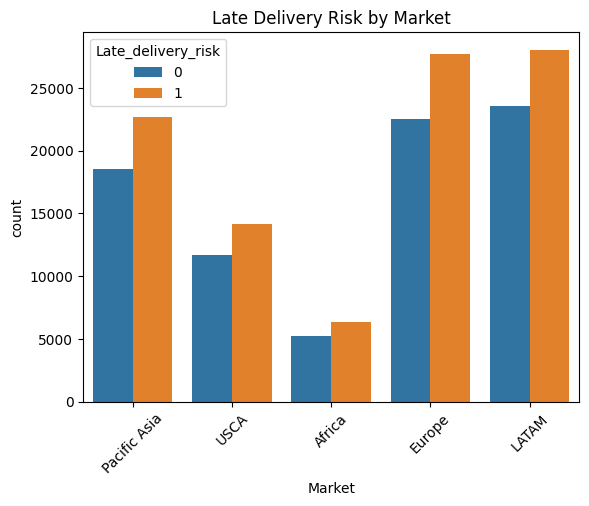

In [11]:
sns.countplot(data=df, x="Market", hue="Late_delivery_risk")
plt.title("Late Delivery Risk by Market")
plt.xticks(rotation=45)
plt.show()

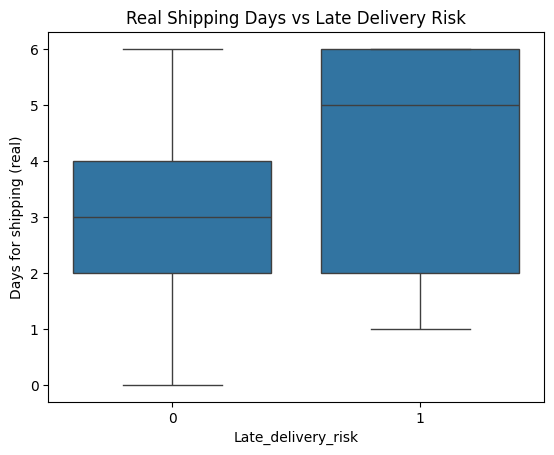

In [12]:
sns.boxplot(data=df, x="Late_delivery_risk", y="Days for shipping (real)")
plt.title("Real Shipping Days vs Late Delivery Risk")
plt.show()

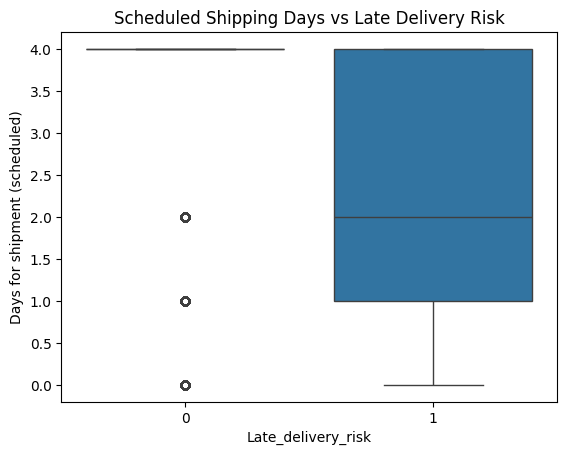

In [14]:
sns.boxplot(data=df, x="Late_delivery_risk", y="Days for shipment (scheduled)")
plt.title("Scheduled Shipping Days vs Late Delivery Risk")
plt.show()

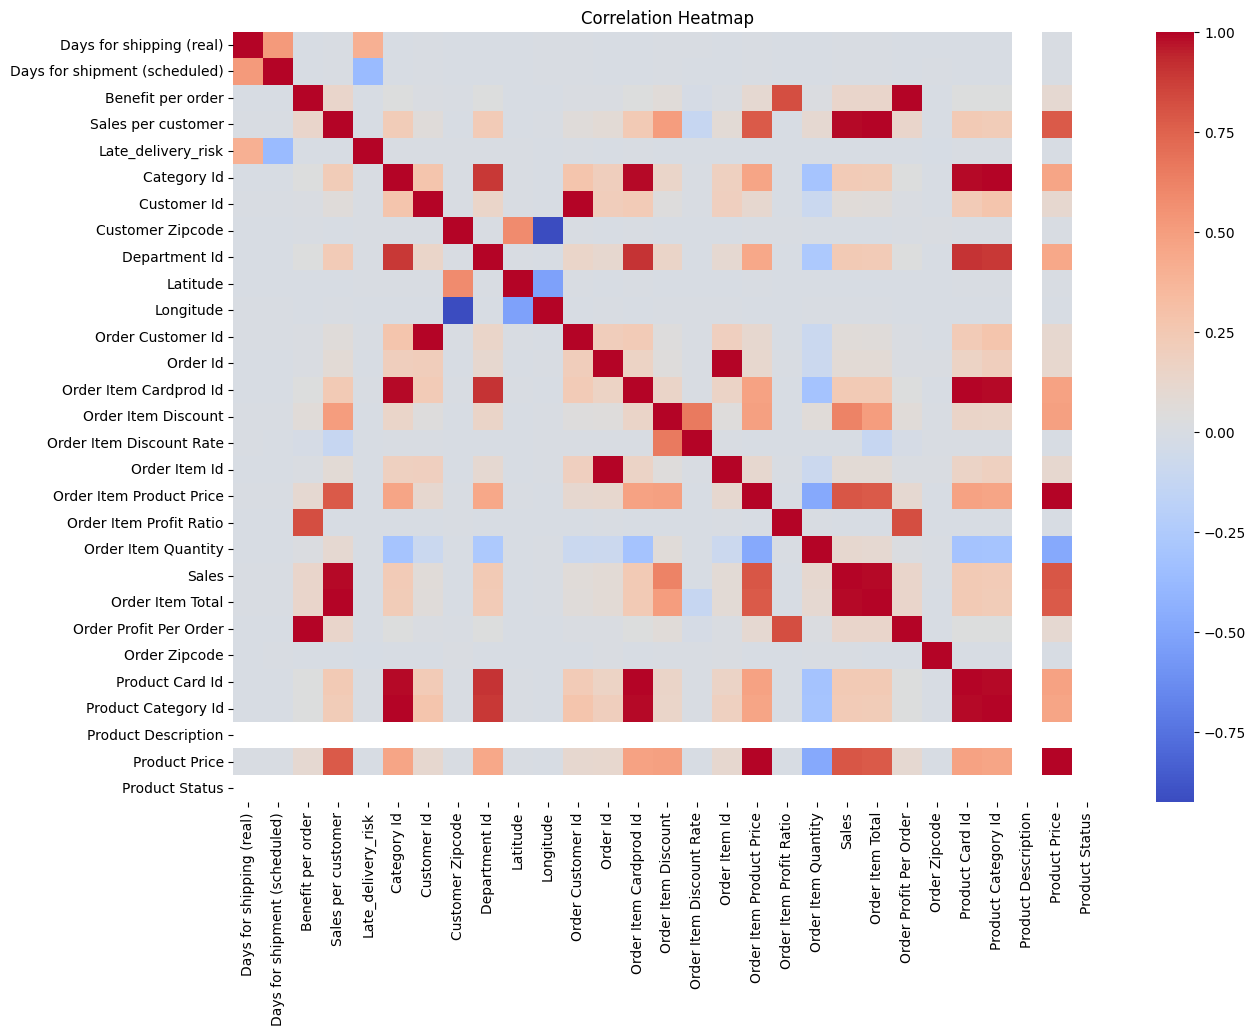

In [15]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, 10))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()